# Wine Quality Analytics
## Which physicochemical characteristics are associated with wine quality, and how could a quality-control lab use them?

**Author:** Ramón Figueroa M. — Biochemical Engineer
**Dataset:** UCI Wine Quality (*Vinho Verde* wines, northwest Portugal)
**Approach:** Data audit, exploratory analysis, non-parametric statistics with effect sizes, and machine learning with leakage-safe validation
**Tools:** Python, pandas, NumPy, SciPy, statsmodels, scikit-learn, Matplotlib, Seaborn

## Executive Summary

This project analyses laboratory measurements of *Vinho Verde* red and white wines together with their sensory quality scores, to identify which physicochemical variables are most associated with quality and how a quality-control (QC) lab could use that information for **screening**.

Key points of the analysis:

1. **Data audit first.** Exact duplicate records are detected and removed *before* any modelling, because identical rows in both training and test sets inflate performance.
2. **Chemistry-aware interpretation.** Variables are interpreted through their enological meaning (e.g. volatile acidity ≈ acetic acid, density ≈ a function of ethanol and sugar, SO₂ efficacy depends on pH). Density is shown to be partly a proxy for alcohol and residual sugar rather than an independent driver.
3. **Robust statistics.** Spearman correlations, Kruskal–Wallis tests with FDR correction and effect sizes, plus the same analysis stratified by wine type to check that pooling red and white wines does not drive the conclusions.
4. **Honest modelling.** Models are compared against a no-skill baseline using ROC-AUC and PR-AUC, the decision threshold is chosen on training data only, and the final test set is used once.

All headline figures are generated automatically in **Section 8 (Results Summary)** from the executed code, so the numbers in this document always match the analysis.

> The analysis is observational: it identifies **associations**, not causal effects or validated production thresholds.

# 1. Business Understanding

## Business problem

In a winery laboratory, physicochemical parameters are cheap and fast to measure on every batch, whereas sensory evaluation by a tasting panel is slower and more expensive. If some measurable variables are consistently associated with sensory quality, they could be used to **prioritise which batches deserve a full sensory evaluation** and which variables deserve closer monitoring.

## Business question

**Which physicochemical characteristics are most strongly associated with wine quality, and how could a QC lab use them to prioritise batches for sensory evaluation?**

## Objectives

1. Audit data quality (missing values, duplicates, chemically implausible records).
2. Describe the distribution of quality scores.
3. Compare the physicochemical profile of red and white wines.
4. Identify variables associated with quality, accounting for correlated predictors.
5. Compare low-, medium- and high-quality wines using robust statistics and effect sizes.
6. Build and evaluate a screening model for high-quality wines (quality ≥ 7).
7. Translate the findings into QC recommendations, with explicit limitations.

# 2. Dataset & Data Understanding

**Source:** Cortez, P., Cerdeira, A., Almeida, F., Matos, T., Reis, J. (2009). *Modeling wine preferences by data mining from physicochemical properties.* Decision Support Systems, 47(4), 547–553. Data available at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/186/wine+quality).

The data describe red and white *Vinho Verde* wines from the Minho region (northwest Portugal). Each record has 11 physicochemical measurements from laboratory analysis and a **sensory quality score (0–10)**, defined by the dataset authors as the median of at least three blind tasting evaluations. No grape variety, brand, vintage or price is available.

### Variable dictionary (chemical meaning)

| Variable | Unit | What it is | Why it may matter for quality |
|---|---|---|---|
| fixed acidity | g/L (tartaric) | Non-volatile organic acids (mainly tartaric and malic) | Freshness, pH, stability |
| volatile acidity | g/L (acetic) | Mainly acetic acid | At high levels gives a vinegar-like off-flavour; indicator of microbial spoilage or fermentation problems |
| citric acid | g/L | Minor organic acid (can also be added) | Freshness and flavour balance |
| residual sugar | g/L | Sugar left after fermentation | Wine style (dry vs. sweet); raises density |
| chlorides | g/L (NaCl) | Salt content | Linked to vineyard conditions and practices; can affect taste |
| free sulfur dioxide | mg/L | Unbound SO₂, active as antioxidant and antimicrobial | Protection against oxidation and spoilage |
| total sulfur dioxide | mg/L | Free + bound SO₂ | Excess can be perceptible and is regulated |
| density | g/cm³ | Mass per volume | Lowered by ethanol, raised by sugar and extract |
| pH | – | Strength of acidity | Controls how much SO₂ is in its active (molecular) form; microbial stability |
| sulphates | g/L (K₂SO₄) | Additive associated with SO₂ and antimicrobial effects | Preservation |
| alcohol | % vol | Ethanol from fermentation of grape sugars | Depends on grape ripeness at harvest; contributes body |
| quality | 0–10 | Sensory score (median of ≥ 3 tasters) | **Target** |

### Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from scipy.stats import kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_theme(style="whitegrid")

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)


def save_show(name):
    """Tidy layout, save the figure (for the README) and display it."""
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [2]:
# Load the red and white datasets from the repository's data/ folder.
DATA_DIRS = [Path("data"), Path("../data"), Path(".")]


def find_file(filename):
    for folder in DATA_DIRS:
        if (folder / filename).exists():
            return folder / filename
    raise FileNotFoundError(
        f"'{filename}' was not found in {[str(d) for d in DATA_DIRS]}. "
        "Place the CSV files in the data/ folder (see README)."
    )


def read_wine_csv(path):
    """Read a wine CSV, detecting whether it is ';' (UCI original) or ',' separated."""
    with open(path, encoding="utf-8") as f:
        sep = ";" if ";" in f.readline() else ","
    return pd.read_csv(path, sep=sep)


red = read_wine_csv(find_file("winequality-red.csv"))
white = read_wine_csv(find_file("winequality-white.csv"))
red["type"] = "red"
white["type"] = "white"

# No identifier column is added at this stage: an ID that is unique per row
# would hide duplicated records from the duplicate check.
wine_raw = pd.concat([red, white], ignore_index=True)

FEATURES = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol",
]

wine_raw.shape

(6497, 13)

In [3]:
wine_raw.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5,red
1,7.800,0.880,0.000,2.600,0.098,25.000,67.000,0.997,3.200,0.680,9.800,5,red
2,7.800,0.760,0.040,2.300,0.092,15.000,54.000,0.997,3.260,0.650,9.800,5,red
3,11.200,0.280,0.560,1.900,0.075,17.000,60.000,0.998,3.160,0.580,9.800,6,red
4,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5,red


In [4]:
wine_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 689.4 KB


In [5]:
wine_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.000,7.215,1.296,3.800,6.400,7.000,7.700,15.900
volatile acidity,6497.000,0.340,0.165,0.080,0.230,0.290,0.400,1.580
citric acid,6497.000,0.319,0.145,0.000,0.250,0.310,0.390,1.660
residual sugar,6497.000,5.443,4.758,0.600,1.800,3.000,8.100,65.800
chlorides,6497.000,0.056,0.035,0.009,0.038,0.047,0.065,0.611
free sulfur dioxide,6497.000,30.525,17.749,1.000,17.000,29.000,41.000,289.000
total sulfur dioxide,6497.000,115.745,56.522,6.000,77.000,118.000,156.000,440.000
density,6497.000,0.995,0.003,0.987,0.992,0.995,0.997,1.039
pH,6497.000,3.219,0.161,2.720,3.110,3.210,3.320,4.010
sulphates,6497.000,0.531,0.149,0.220,0.430,0.510,0.600,2.000


# 3. Data Quality & Cleaning

The audit covers four checks: missing values, **exact duplicates**, chemical plausibility, and outliers.

## 3.1 Missing values

In [6]:
display(wine_raw.isnull().sum().to_frame("missing values"))

,missing values
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


## 3.2 Duplicated records

Duplicates are searched across **all** measured columns plus wine type, with no identifier column present.
Exact duplicates are a problem for supervised learning: when copies of the same record land in both the training and test sets, the model is evaluated on rows it has effectively already seen, which inflates performance, especially for high-capacity models such as Random Forest.

In [7]:
n_raw = len(wine_raw)
dup_mask = wine_raw.duplicated(keep="first")
n_dup = int(dup_mask.sum())

print(f"Exact duplicate rows: {n_dup:,} of {n_raw:,} ({n_dup / n_raw:.1%})")

dup_by_type = pd.DataFrame({
    "rows": wine_raw["type"].value_counts(),
    "duplicate_rows": wine_raw.loc[dup_mask, "type"].value_counts(),
}).fillna(0).astype(int)
dup_by_type["duplicate_%"] = dup_by_type["duplicate_rows"] / dup_by_type["rows"] * 100
dup_by_type

Exact duplicate rows: 1,177 of 6,497 (18.1%)


,rows,duplicate_rows,duplicate_%
type,,,
white,4898,937,19.130
red,1599,240,15.009


In [8]:
# Do identical physicochemical profiles ever receive different quality scores?
profile_quality = wine_raw.groupby(FEATURES + ["type"])["quality"].nunique()
n_conflicts = int((profile_quality > 1).sum())
print(f"Physicochemical profiles with conflicting quality scores: {n_conflicts}")

Physicochemical profiles with conflicting quality scores: 0


### Decision on duplicates

The dataset has no sample identifier, so it is not possible to know whether a repeated record is a data-entry duplicate or a genuine replicate sample. Because the measurements are reported to several decimals and the records are identical in all 12 columns, they are treated as **repeated records**.

**Decision:** remove exact duplicates for the main analysis.

In [9]:
wine = wine_raw.drop_duplicates().reset_index(drop=True)
n_clean = len(wine)

print(f"Records after removing duplicates: {n_clean:,} (removed {n_raw - n_clean:,})")
wine["type"].value_counts().to_frame("unique wines")

Records after removing duplicates: 5,320 (removed 1,177)


,unique wines
type,
white,3961
red,1359


## 3.3 Chemical plausibility checks

Beyond statistical checks, records are validated against basic chemical constraints (for example, free SO₂ is a subset of total SO₂, so it can never exceed it).

In [10]:
validity = pd.Series({
    "free SO2 > total SO2 (impossible)": int((wine["free sulfur dioxide"] > wine["total sulfur dioxide"]).sum()),
    "pH outside 2.5–4.5": int((~wine["pH"].between(2.5, 4.5)).sum()),
    "alcohol outside 5–20 % vol": int((~wine["alcohol"].between(5, 20)).sum()),
    "density above 1.01 g/cm³": int((wine["density"] > 1.01).sum()),
}, name="records flagged")

display(validity.to_frame())

# Extremely dense wines should coincide with very high residual sugar (sweet wine)
wine.loc[wine["density"] > 1.01, ["type", "residual sugar", "density", "alcohol", "quality"]]

,records flagged
free SO2 > total SO2 (impossible),0
pH outside 2.5–4.5,0
alcohol outside 5–20 % vol,0
density above 1.01 g/cm³,2


,type,residual sugar,density,alcohol,quality
2753,white,31.600,1.010,8.800,6
3653,white,65.800,1.039,11.700,6


## 3.4 Outliers (IQR rule)

Outliers are flagged with the IQR rule but **not removed**: in a chemical dataset an extreme value is not necessarily an error. For example, very high residual sugar is consistent with a sweet wine, and high SO₂ can reflect winemaking style or a sweet wine that needs more protection. Removing them would delete legitimate chemical diversity. The plausibility checks above are what justify discarding a record, and any flagged record would need confirmation with the laboratory.

In [11]:
outlier_rows = []

for column in FEATURES:
    q1, q3 = wine[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((wine[column] < lower) | (wine[column] > upper)).sum())
    outlier_rows.append({
        "variable": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": n_out,
        "outlier_%": n_out / len(wine) * 100,
    })

pd.DataFrame(outlier_rows).sort_values("outlier_%", ascending=False)

,variable,lower_bound,upper_bound,outlier_count,outlier_%
0,fixed acidity,4.450,9.650,304,5.714
1,volatile acidity,-0.040,0.680,279,5.244
4,chlorides,-0.004,0.108,237,4.455
9,sulphates,0.175,0.855,163,3.064
2,citric acid,-0.000,0.640,143,2.688
3,residual sugar,-6.750,16.050,141,2.650
8,pH,2.780,3.660,49,0.921
5,free sulfur dioxide,-21.500,78.500,44,0.827
6,total sulfur dioxide,-44.875,272.125,10,0.188
7,density,0.985,1.004,3,0.056


# 4. Exploratory Data Analysis

## 4.1 Distribution of quality scores

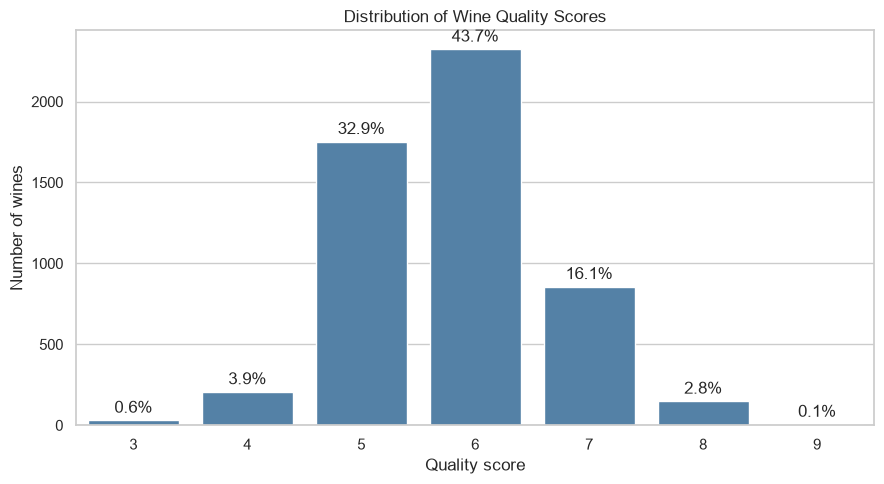

In [12]:
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=wine, x="quality", color="steelblue")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{bar.get_height() / len(wine) * 100:.1f}%" for bar in container],
        padding=3,
    )

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality score")
plt.ylabel("Number of wines")
save_show("01_quality_distribution")

In [13]:
quality_by_type = pd.crosstab(wine["quality"], wine["type"], normalize="columns") * 100
quality_by_type.round(1)

type,red,white
quality,,
3,0.700,0.500
4,3.900,3.900
5,42.500,29.700
6,39.400,45.100
7,12.300,17.400
8,1.300,3.300
9,0.000,0.100


Scores of 5, 6 and 7 account for most wines, while the extremes (3, 4, 8, 9) are rare. Conclusions about the rarest scores, especially 9, rest on very few observations and must be read with caution. The distribution also differs between wine types, which is why the analysis is checked separately for red and white wines.

## 4.2 Red vs. white wines

The comparison uses the Mann–Whitney U test (no normality assumption) for all 11 variables, with Benjamini–Hochberg FDR correction, and **Cliff's delta** as effect size. Cliff's delta is computed directly from the U statistic: δ = 2U / (n₁·n₂) − 1.

In [14]:
def cliffs_magnitude(delta):
    d = abs(delta)
    if d < 0.147:
        return "negligible"
    if d < 0.33:
        return "small"
    if d < 0.474:
        return "medium"
    return "large"


red_df = wine[wine["type"] == "red"]
white_df = wine[wine["type"] == "white"]
n_red, n_white = len(red_df), len(white_df)

type_rows = []
for column in FEATURES:
    u_stat, p_val = mannwhitneyu(red_df[column], white_df[column], alternative="two-sided")
    type_rows.append({
        "variable": column,
        "median_red": red_df[column].median(),
        "median_white": white_df[column].median(),
        "p_value": p_val,
        "cliffs_delta": 2 * u_stat / (n_red * n_white) - 1,   # positive: red tends to be higher
    })

type_tests = pd.DataFrame(type_rows)
type_tests["p_adjusted"] = multipletests(type_tests["p_value"], method="fdr_bh")[1]
type_tests["magnitude"] = type_tests["cliffs_delta"].apply(cliffs_magnitude)
type_tests = type_tests.sort_values("cliffs_delta", key=abs, ascending=False).reset_index(drop=True)
type_tests

,variable,median_red,median_white,p_value,cliffs_delta,p_adjusted,magnitude
0,total sulfur dioxide,38.000,133.000,0.000,-0.899,0.000,large
1,chlorides,0.079,0.042,0.000,0.884,0.000,large
2,volatile acidity,0.520,0.260,0.000,0.796,0.000,large
3,free sulfur dioxide,14.000,33.000,0.000,-0.684,0.000,large
4,sulphates,0.620,0.480,0.000,0.661,0.000,large
5,density,0.997,0.994,0.000,0.600,0.000,large
6,fixed acidity,7.900,6.800,0.000,0.568,0.000,large
7,pH,3.310,3.180,0.000,0.422,0.000,medium
8,residual sugar,2.200,4.700,0.000,-0.291,0.000,small
9,citric acid,0.260,0.320,0.000,-0.209,0.000,small


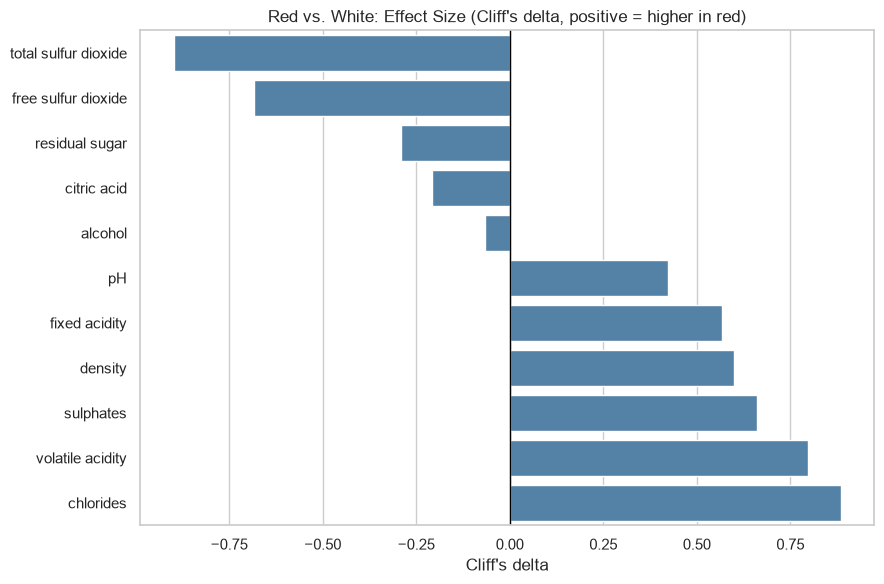

In [15]:
plt.figure(figsize=(9, 6))
plot_data = type_tests.sort_values("cliffs_delta")
sns.barplot(data=plot_data, x="cliffs_delta", y="variable", color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.title("Red vs. White: Effect Size (Cliff's delta, positive = higher in red)")
plt.xlabel("Cliff's delta")
plt.ylabel("")
save_show("02_red_vs_white_effect_size")

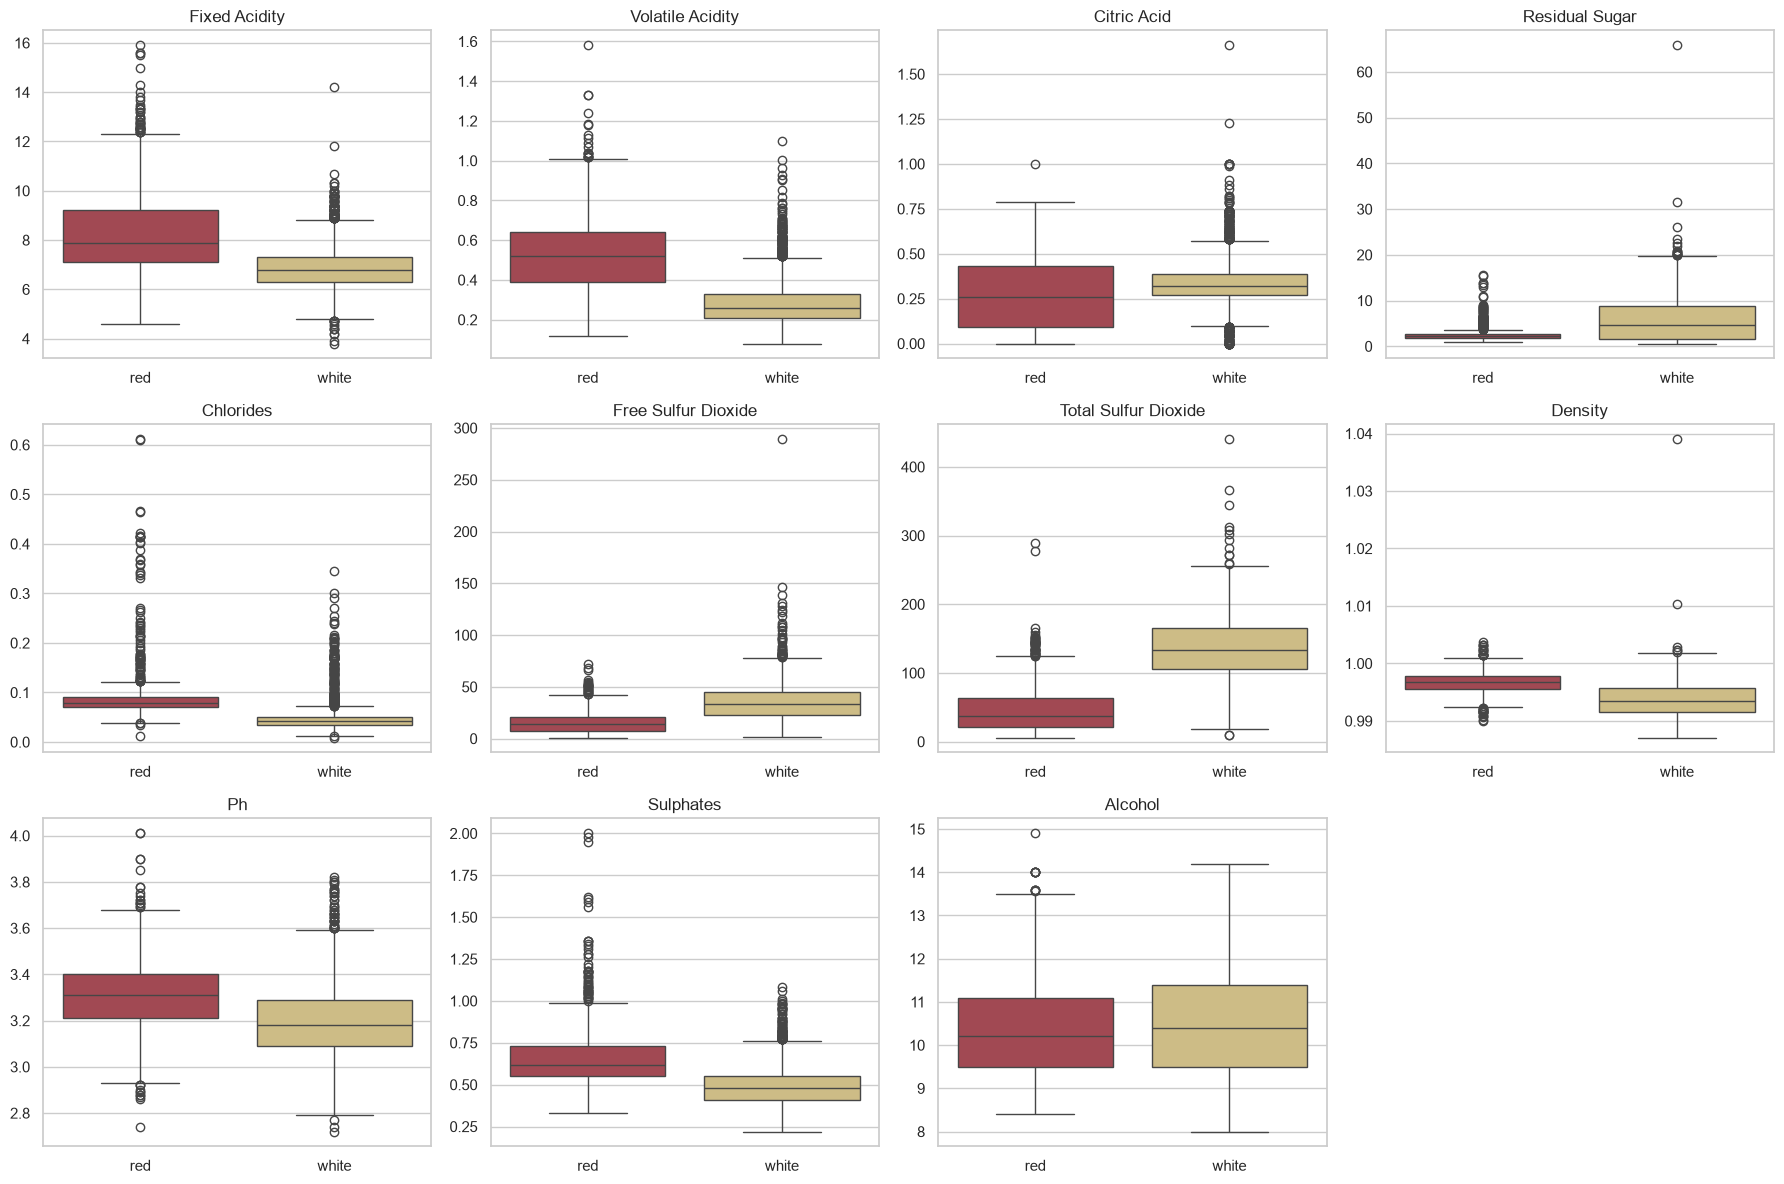

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

for ax, variable in zip(axes.flatten(), FEATURES):
    sns.boxplot(data=wine, x="type", y=variable, ax=ax, palette=["#b03a48", "#d9c27a"], hue="type", legend=False)
    ax.set_title(variable.title())
    ax.set_xlabel("")
    ax.set_ylabel("")

axes.flatten()[-1].axis("off")
save_show("03_red_vs_white_boxplots")

In [17]:
negligible_vars = type_tests.loc[type_tests["magnitude"] == "negligible", "variable"].tolist()
large_vars = type_tests.loc[type_tests["magnitude"] == "large", "variable"].tolist()

display(Markdown(
    f"**Large differences between red and white:** {', '.join(large_vars) if large_vars else 'none'}.  \n"
    f"**Negligible differences:** {', '.join(negligible_vars) if negligible_vars else 'none'}."
))

**Large differences between red and white:** total sulfur dioxide, chlorides, volatile acidity, free sulfur dioxide, sulphates, density, fixed acidity.  
**Negligible differences:** alcohol.

### Interpretation

Red and white wines are chemically different products, and the differences are consistent with winemaking practice. Red wines typically show higher volatile and fixed acidity. White wines typically carry more residual sugar and considerably more SO₂, which is expected because red wines contain phenolic compounds with their own antioxidant capacity, so whites rely more on added SO₂ for protection.

This matters for the rest of the analysis: a variable can differ a lot between types without being related to quality, and pooling two chemically different populations can create or hide associations. For that reason, the main associations are re-checked **within each wine type** (Sections 4.3 and 5.3).

## 4.3 Quality vs. physicochemical variables

Quality is an **ordinal** sensory score, so Spearman rank correlation is used instead of Pearson. It is computed for all wines and separately for each type.

In [18]:
spearman_all = wine[FEATURES].corrwith(wine["quality"], method="spearman")
spearman_red = red_df[FEATURES].corrwith(red_df["quality"], method="spearman")
spearman_white = white_df[FEATURES].corrwith(white_df["quality"], method="spearman")

corr_table = pd.DataFrame({
    "all wines": spearman_all,
    "red": spearman_red,
    "white": spearman_white,
}).sort_values("all wines", ascending=False)

corr_table

,all wines,red,white
alcohol,0.480,0.488,0.476
citric acid,0.116,0.219,0.030
free sulfur dioxide,0.090,-0.059,0.033
pH,0.053,-0.043,0.136
sulphates,0.036,0.381,0.036
residual sugar,-0.028,0.026,-0.092
total sulfur dioxide,-0.058,-0.197,-0.203
fixed acidity,-0.104,0.112,-0.094
volatile acidity,-0.251,-0.387,-0.185
chlorides,-0.304,-0.204,-0.333


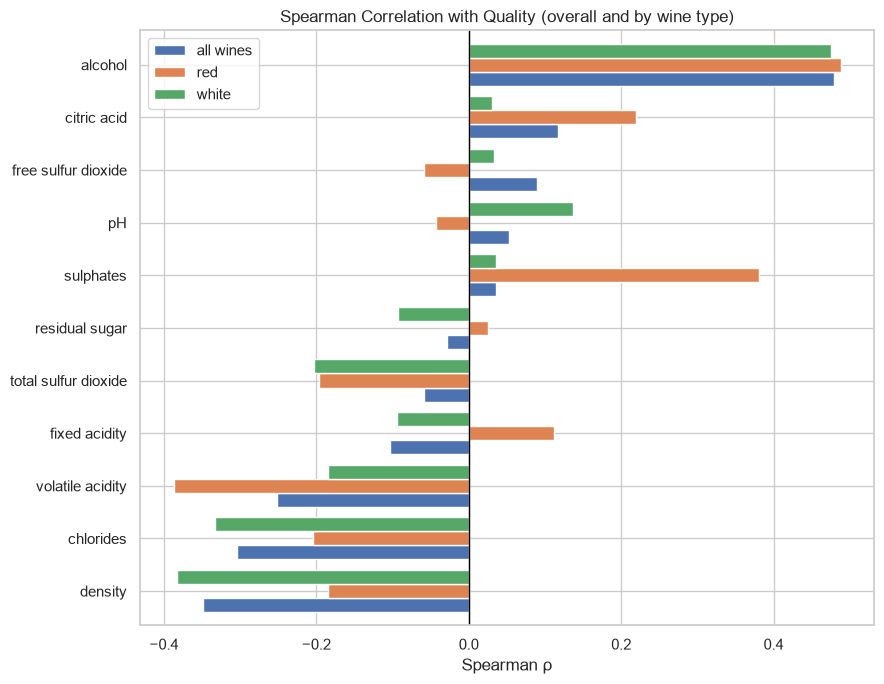

In [19]:
corr_table.sort_values("all wines").plot(kind="barh", figsize=(9, 7), width=0.8)
plt.axvline(0, color="black", linewidth=1)
plt.title("Spearman Correlation with Quality (overall and by wine type)")
plt.xlabel("Spearman ρ")
plt.ylabel("")
save_show("04_spearman_with_quality")

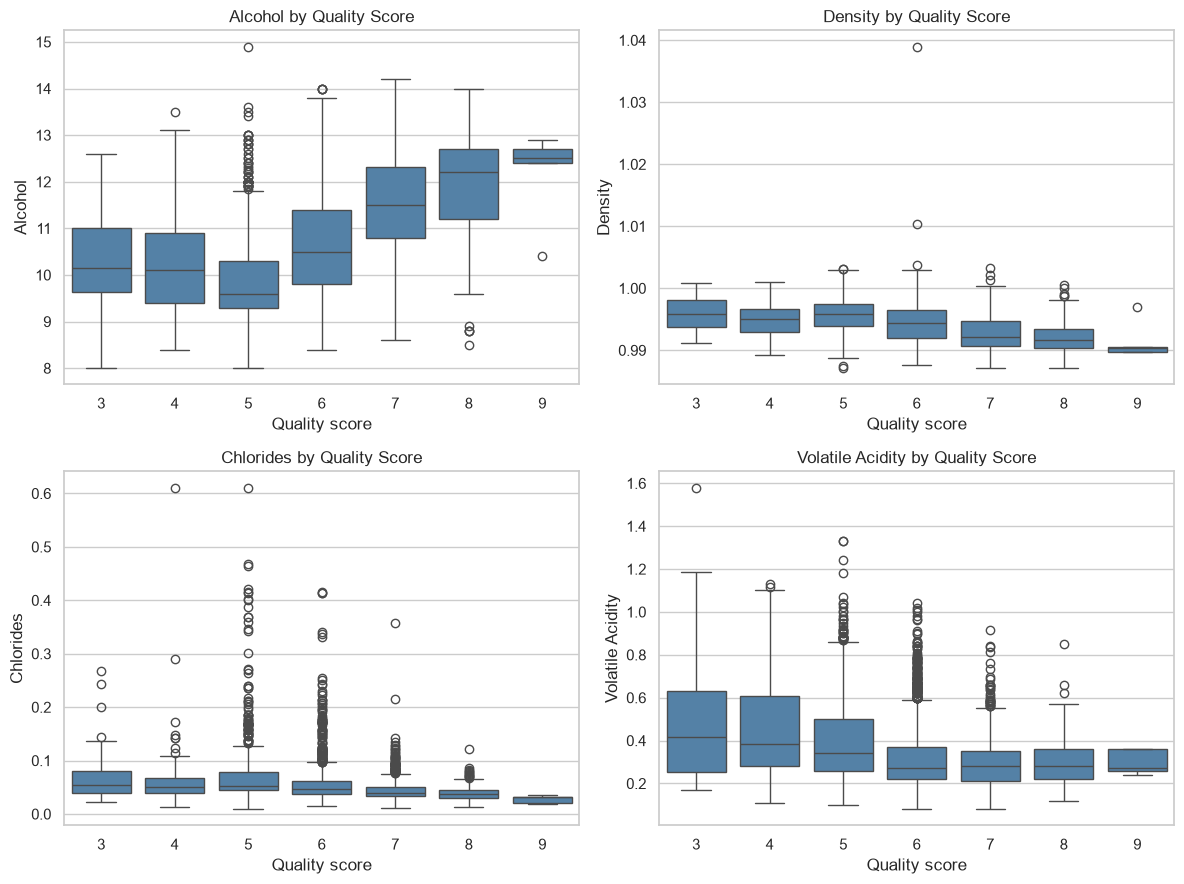

In [20]:
KEY_VARIABLES = ["alcohol", "density", "chlorides", "volatile acidity"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, variable in zip(axes.flatten(), KEY_VARIABLES):
    sns.boxplot(data=wine, x="quality", y=variable, color="steelblue", ax=ax)
    ax.set_title(f"{variable.title()} by Quality Score")
    ax.set_xlabel("Quality score")
    ax.set_ylabel(variable.title())
save_show("05_key_variables_by_quality")

The distributions shift with quality, but they overlap considerably between scores. These variables are therefore **associated** with quality but are not deterministic thresholds.

## 4.4 Multicollinearity among predictors

Many winemaking variables are chemically linked (alcohol, sugar and density; free and total SO₂; pH and acids). Correlated predictors make it hard to attribute importance to any single one, so this is checked explicitly with a correlation matrix and Variance Inflation Factors (VIF).

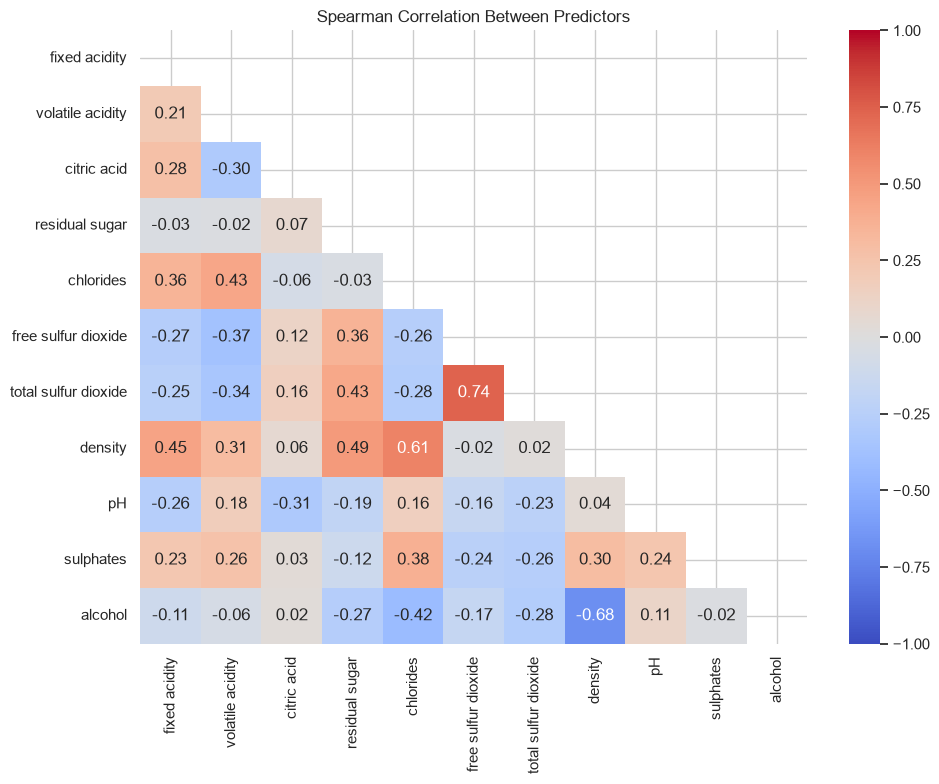

In [21]:
pred_corr = wine[FEATURES].corr(method="spearman")
mask = np.triu(np.ones_like(pred_corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(pred_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Spearman Correlation Between Predictors")
save_show("06_predictor_correlation")

In [22]:
X_vif = add_constant(wine[FEATURES])
vif_table = pd.DataFrame({
    "variable": FEATURES,
    "VIF": [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(FEATURES))],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_table

,variable,VIF
0,density,14.922
1,residual sugar,6.428
2,fixed acidity,4.882
3,alcohol,4.575
4,total sulfur dioxide,2.933
5,pH,2.480
6,free sulfur dioxide,2.136
7,volatile acidity,1.957
8,citric acid,1.655
9,chlorides,1.632


A VIF above roughly 5 to 10 indicates that a variable is largely explained by the others. Density typically stands out, which is the next question.

## 4.5 Density: an independent driver or a proxy?

Physically, the density of a wine is determined mainly by its **ethanol** content (ethanol is less dense than water, so more alcohol lowers density) and its **dissolved sugars and extract** (which raise it). If alcohol and residual sugar explain most of the variance in density, then density's association with quality is mostly the footprint of those two variables rather than an independent effect.

In [23]:
density_rows = []
for label, df in [("all wines", wine), ("red", red_df), ("white", white_df)]:
    reg = LinearRegression().fit(df[["alcohol", "residual sugar"]], df["density"])
    density_rows.append({
        "subset": label,
        "R² of density ~ alcohol + residual sugar": reg.score(df[["alcohol", "residual sugar"]], df["density"]),
    })

density_r2 = pd.DataFrame(density_rows).set_index("subset")
density_r2

,R² of density ~ alcohol + residual sugar
subset,
all wines,0.557
red,0.383
white,0.897


In [24]:
r2_all = density_r2.loc["all wines"].iloc[0]
strength = "largely" if r2_all >= 0.75 else "partly" if r2_all >= 0.40 else "only slightly"

display(Markdown(
    f"Alcohol and residual sugar alone explain **{r2_all:.0%}** of the variance in density across all wines, "
    f"so density is **{strength}** a proxy for them; the remainder reflects other compositional effects "
    "(and the mix of red and white wines). It should be read as a cheap routine indicator, not as an "
    "independent factor that winemakers could adjust on its own."
))

Alcohol and residual sugar alone explain **56%** of the variance in density across all wines, so density is **partly** a proxy for them; the remainder reflects other compositional effects (and the mix of red and white wines). It should be read as a cheap routine indicator, not as an independent factor that winemakers could adjust on its own.

## 4.6 Domain-informed features: molecular SO₂

Free SO₂ protects a wine only in its **molecular** form (SO₂ dissolved as a gas), and the fraction present as molecular SO₂ depends strongly on pH. Using the Henderson–Hasselbalch relation with a commonly used pKa₁ ≈ 1.81:

$$\text{molecular SO}_2 = \frac{\text{free SO}_2}{1 + 10^{(\text{pH} - 1.81)}}$$

A wine with the same free SO₂ but higher pH therefore has far less effective protection. Two engineered features are created and tested later as additional predictors: `molecular_so2` and `free_to_total_so2` (the fraction of SO₂ that is still unbound).

In [25]:
PKA1_SO2 = 1.81

wine["molecular_so2"] = wine["free sulfur dioxide"] / (1 + 10 ** (wine["pH"] - PKA1_SO2))
wine["free_to_total_so2"] = wine["free sulfur dioxide"] / wine["total sulfur dioxide"]
ENGINEERED = ["molecular_so2", "free_to_total_so2"]

display(wine.groupby("type")[ENGINEERED].median())
wine[ENGINEERED + ["quality"]].corr(method="spearman")["quality"].drop("quality").to_frame("Spearman ρ with quality")

,molecular_so2,free_to_total_so2
type,,
red,0.399,0.375
white,1.268,0.252


,Spearman ρ with quality
molecular_so2,0.054
free_to_total_so2,0.149


# 5. Statistical Analysis

## 5.1 Quality segmentation

For group comparisons the score is grouped into three segments:

- **Low:** quality ≤ 5
- **Medium:** quality = 6
- **High:** quality ≥ 7

This is an analytical definition, not a validated production standard.

In [26]:
SEGMENT_ORDER = ["Low", "Medium", "High"]

wine["quality_segment"] = np.select(
    [wine["quality"] <= 5, wine["quality"] == 6],
    ["Low", "Medium"],
    default="High",
)

segment_counts = wine["quality_segment"].value_counts().reindex(SEGMENT_ORDER)
pd.DataFrame({"count": segment_counts, "percentage": segment_counts / len(wine) * 100})

,count,percentage
quality_segment,,
Low,1988,37.368
Medium,2323,43.665
High,1009,18.966


In [27]:
wine.groupby("quality_segment")[KEY_VARIABLES].median().reindex(SEGMENT_ORDER)

,alcohol,density,chlorides,volatile acidity
quality_segment,,,,
Low,9.700,0.996,0.053,0.340
Medium,10.500,0.994,0.046,0.270
High,11.600,0.992,0.038,0.280


## 5.2 Kruskal–Wallis test with effect size

The Kruskal–Wallis test checks whether each variable's distribution differs across the three segments. Because 11 variables are tested, p-values are adjusted with the Benjamini–Hochberg FDR procedure.

The effect size reported is **η²ₕ = (H − k + 1) / (n − k)** (Tomczak & Tomczak, 2014), interpreted with the usual conventions: < 0.01 negligible, 0.01–0.06 small, 0.06–0.14 medium, ≥ 0.14 large.

In [28]:
def eta2_magnitude(value):
    if value < 0.01:
        return "negligible"
    if value < 0.06:
        return "small"
    if value < 0.14:
        return "medium"
    return "large"


def kruskal_by_segment(df, column):
    groups = [df.loc[df["quality_segment"] == s, column] for s in SEGMENT_ORDER]
    h_stat, p_val = kruskal(*groups)
    n, k = len(df), len(SEGMENT_ORDER)
    return h_stat, p_val, (h_stat - k + 1) / (n - k)


kw_rows = []
for column in FEATURES:
    h_stat, p_val, eta2 = kruskal_by_segment(wine, column)
    kw_rows.append({"variable": column, "H": h_stat, "p_value": p_val, "eta2_H": eta2})

eta_table = pd.DataFrame(kw_rows)
eta_table["p_adjusted"] = multipletests(eta_table["p_value"], method="fdr_bh")[1]
eta_table["magnitude"] = eta_table["eta2_H"].apply(eta2_magnitude)
eta_table = eta_table.sort_values("eta2_H", ascending=False).reset_index(drop=True)
eta_table

,variable,H,p_value,eta2_H,p_adjusted,magnitude
0,alcohol,1302.299,0.000,0.245,0.000,large
1,density,700.553,0.000,0.131,0.000,medium
2,chlorides,518.634,0.000,0.097,0.000,medium
3,volatile acidity,369.795,0.000,0.069,0.000,medium
4,citric acid,67.160,0.000,0.012,0.000,small
5,fixed acidity,57.651,0.000,0.010,0.000,small
6,free sulfur dioxide,33.663,0.000,0.006,0.000,negligible
7,total sulfur dioxide,29.426,0.000,0.005,0.000,negligible
8,pH,19.069,0.000,0.003,0.000,negligible
9,residual sugar,10.877,0.004,0.002,0.005,negligible


C:\Users\Ramón\AppData\Local\Temp\ipykernel_16892\1161094981.py:56: UserWarning: Glyph 8341 (\N{LATIN SUBSCRIPT SMALL LETTER H}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ramón\AppData\Local\Temp\ipykernel_16892\1161094981.py:57: UserWarning: Glyph 8341 (\N{LATIN SUBSCRIPT SMALL LETTER H}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
c:\Users\Ramón\Downloads\wine-quality-app\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8341 (\N{LATIN SUBSCRIPT SMALL LETTER H}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


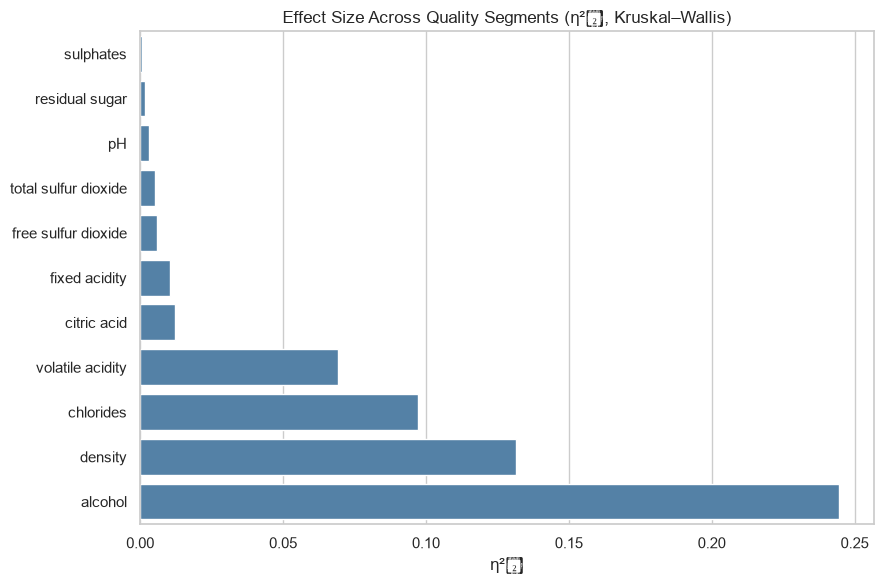

In [29]:
plt.figure(figsize=(9, 6))
sns.barplot(data=eta_table.sort_values("eta2_H"), x="eta2_H", y="variable", color="steelblue")
plt.title("Effect Size Across Quality Segments (η²ₕ, Kruskal–Wallis)")
plt.xlabel("η²ₕ")
plt.ylabel("")
save_show("07_kruskal_effect_size")

In [30]:
n_sig = int((eta_table["p_adjusted"] < 0.05).sum())
display(Markdown(
    f"After FDR correction, **{n_sig} of {len(FEATURES)}** variables differ significantly across quality segments. "
    "With several thousand observations almost any difference reaches significance, so the **effect size** is "
    "what separates relevant from trivial differences."
))

After FDR correction, **11 of 11** variables differ significantly across quality segments. With several thousand observations almost any difference reaches significance, so the **effect size** is what separates relevant from trivial differences.

## 5.3 Robustness: the same test within each wine type

If an association appeared only in the pooled data, it could simply reflect that red and white wines differ in both chemistry and quality distribution. The effect sizes are therefore recomputed separately for red and white wines.

In [31]:
by_type_rows = []
for label, df in [("red", red_df), ("white", white_df)]:
    df = df.copy()
    df["quality_segment"] = wine.loc[df.index, "quality_segment"]
    for column in FEATURES:
        _, _, eta2 = kruskal_by_segment(df, column)
        by_type_rows.append({"variable": column, "type": label, "eta2_H": eta2})

eta_by_type = (
    pd.DataFrame(by_type_rows)
    .pivot(index="variable", columns="type", values="eta2_H")
    .join(eta_table.set_index("variable")["eta2_H"].rename("pooled"))
    .sort_values("pooled", ascending=False)
)
eta_by_type

,red,white,pooled
variable,,,
alcohol,0.263,0.237,0.245
density,0.038,0.158,0.131
chlorides,0.045,0.117,0.097
volatile acidity,0.143,0.050,0.069
citric acid,0.049,0.000,0.012
fixed acidity,0.015,0.008,0.010
free sulfur dioxide,0.007,0.001,0.006
total sulfur dioxide,0.051,0.048,0.005
pH,0.003,0.019,0.003


C:\Users\Ramón\AppData\Local\Temp\ipykernel_16892\1161094981.py:56: UserWarning: Glyph 8341 (\N{LATIN SUBSCRIPT SMALL LETTER H}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ramón\AppData\Local\Temp\ipykernel_16892\1161094981.py:57: UserWarning: Glyph 8341 (\N{LATIN SUBSCRIPT SMALL LETTER H}) missing from font(s) Arial.
  plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
c:\Users\Ramón\Downloads\wine-quality-app\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 8341 (\N{LATIN SUBSCRIPT SMALL LETTER H}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


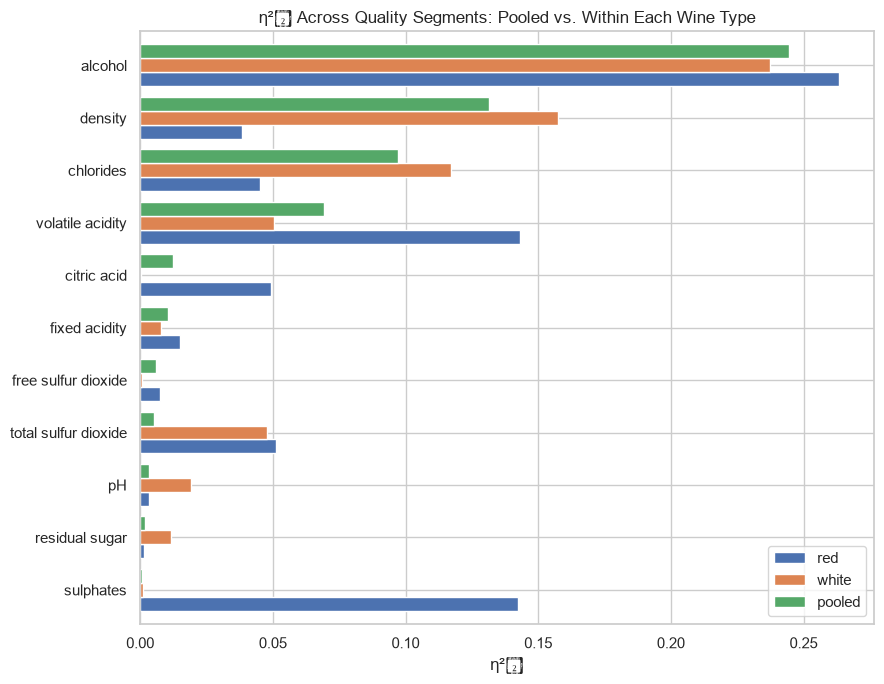

In [32]:
eta_by_type.sort_values("pooled").plot(kind="barh", figsize=(9, 7), width=0.8)
plt.title("η²ₕ Across Quality Segments: Pooled vs. Within Each Wine Type")
plt.xlabel("η²ₕ")
plt.ylabel("")
save_show("08_eta2_by_type")

Variables whose effect size is similar in the pooled analysis and within both types can be considered robust to the red/white mixture. Variables whose effect changes markedly between types should be reported with that caveat.

# 6. Predictive Modeling

## 6.1 Target definition

The model is framed as a **screening tool**: identify wines with quality ≥ 7 so that the sensory panel can prioritise them.

**High quality = quality ≥ 7** (analytical definition, not a validated production threshold).

In [33]:
wine["high_quality"] = (wine["quality"] >= 7).astype(int)

target_counts = wine["high_quality"].value_counts().sort_index()
prevalence = wine["high_quality"].mean()

display(pd.DataFrame({"count": target_counts, "percentage": target_counts / len(wine) * 100}))
print(f"A model that always predicts 'not high quality' reaches {1 - prevalence:.1%} accuracy, so accuracy alone is not informative.")

,count,percentage
high_quality,,
0,4311,81.034
1,1009,18.966


A model that always predicts 'not high quality' reaches 81.0% accuracy, so accuracy alone is not informative.


## 6.2 Features and leakage control

The 11 original physicochemical variables are used as predictors.

Excluded: `quality` and `quality_segment` (they define the target: leakage), `high_quality` (the target), and `type`, to keep the model focused on laboratory chemistry (see Limitations).

Duplicates were removed before the split (Section 3.2) so no record can appear in both training and test sets.

In [34]:
X = wine[FEATURES].copy()
y = wine["high_quality"].copy()
X.shape, y.shape

((5320, 11), (5320,))

## 6.3 Train–test split

Stratified 80/20 split, stratifying by **target and wine type** together so both are balanced across the sets. The test set is used only for final evaluation.

In [35]:
strata = y.astype(str) + "_" + wine["type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=strata
)

print("Training set:", X_train.shape, "| Test set:", X_test.shape)
print(f"High-quality share: train {y_train.mean():.3f} | test {y_test.mean():.3f}")

Training set: (4256, 11) | Test set: (1064, 11)
High-quality share: train 0.190 | test 0.190


## 6.4 Baseline and candidate models

- **Dummy classifier:** no-skill baseline (always predicts the prior). Any useful model must beat its ROC-AUC (0.5) and PR-AUC (≈ prevalence).
- **Logistic Regression:** interpretable linear model (scaled inputs, balanced class weights).
- **Random Forest:** non-linear model able to capture interactions (balanced class weights).

Besides accuracy, precision, recall and F1, **ROC-AUC** and **PR-AUC** are reported because they do not depend on a single threshold, and PR-AUC is the more informative one for an imbalanced target.

In [36]:
def make_logreg():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ])


def make_rf():
    return RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE
    )


def evaluate(model, X_eval, y_eval, threshold=0.5, name=None):
    proba = model.predict_proba(X_eval)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_eval, pred),
        "Precision": precision_score(y_eval, pred, zero_division=0),
        "Recall": recall_score(y_eval, pred, zero_division=0),
        "F1": f1_score(y_eval, pred, zero_division=0),
        "F2": fbeta_score(y_eval, pred, beta=2, zero_division=0),
        "ROC-AUC": roc_auc_score(y_eval, proba),
        "PR-AUC": average_precision_score(y_eval, proba),
    }


fitted = {
    "Dummy (baseline)": DummyClassifier(strategy="prior"),
    "Logistic Regression": make_logreg(),
    "Random Forest (default)": make_rf(),
}

for model in fitted.values():
    model.fit(X_train, y_train)

## 6.5 Random Forest tuning

Hyperparameters are tuned with randomized search and 5-fold stratified cross-validation on the **training set only**, optimizing PR-AUC (average precision). The test set plays no role in this step.

In [37]:
param_distributions = {
    "n_estimators": [300, 500],
    "max_depth": [None, 8, 12, 16, 24],
    "min_samples_leaf": [1, 2, 3, 5, 10],
    "max_features": ["sqrt", "log2", 0.5],
}

search = RandomizedSearchCV(
    make_rf(),
    param_distributions=param_distributions,
    n_iter=20,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)
print(f"Best cross-validated PR-AUC (training data): {search.best_score_:.3f}")

fitted["Random Forest (tuned)"] = search.best_estimator_

Best parameters: {'n_estimators': 300, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
Best cross-validated PR-AUC (training data): 0.586


## 6.6 Holdout performance (default threshold 0.5)

In [38]:
holdout_table = pd.DataFrame(
    [evaluate(model, X_test, y_test, name=name) for name, model in fitted.items()]
).set_index("Model")

holdout_table

,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
Model,,,,,,,
Dummy (baseline),0.810,0.000,0.000,0.000,0.000,0.500,0.190
Logistic Regression,0.725,0.391,0.807,0.527,0.665,0.831,0.530
Random Forest (default),0.838,0.565,0.644,0.602,0.626,0.867,0.641
Random Forest (tuned),0.820,0.520,0.658,0.581,0.625,0.866,0.629


**Reading the comparison.** Hyperparameter tuning did not materially improve the Random Forest: the tuned and default models are practically identical on threshold-independent metrics (PR-AUC 0.62 vs 0.63; ROC-AUC 0.86 for both). The differences at the fixed 0.50 cutoff (e.g. recall 0.50 vs 0.40) mostly reflect where each model's probabilities fall relative to that cutoff rather than better ranking, which is why the threshold is analysed explicitly in Section 6.7. The tuned model is kept as the final model because it was selected using training data only; choosing between near-identical models by test-set score would leak information from the test set.

Logistic Regression reaches higher recall at 0.50 only because class weighting shifts its probabilities upwards, at the cost of precision. On threshold-independent metrics the Random Forest is clearly better (PR-AUC 0.63 vs 0.53), which suggests non-linear effects or interactions among the variables.

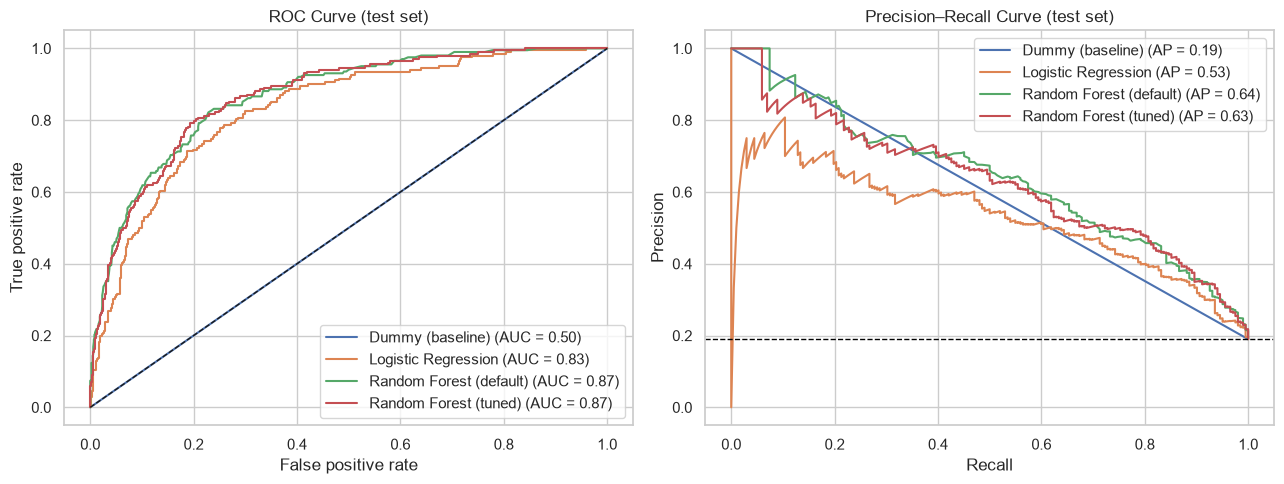

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, model in fitted.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, proba):.2f})")
    axes[1].plot(rec, prec, label=f"{name} (AP = {average_precision_score(y_test, proba):.2f})")

axes[0].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[0].set(title="ROC Curve (test set)", xlabel="False positive rate", ylabel="True positive rate")
axes[1].axhline(y_test.mean(), color="black", linestyle="--", linewidth=1)
axes[1].set(title="Precision–Recall Curve (test set)", xlabel="Recall", ylabel="Precision")
axes[0].legend(loc="lower right")
axes[1].legend(loc="upper right")
save_show("09_roc_pr_curves")

The dashed line in the right panel is the no-skill level (equal to the prevalence of high-quality wines). The gap between each model and that line is the real value added by the model.

## 6.7 Choosing the decision threshold

A threshold of 0.5 is arbitrary. For a **screening** use case, a missed high-quality wine (false negative) is assumed to be costlier than sending an extra batch to the sensory panel (false positive), so the threshold is chosen to maximise **F2**, which weights recall twice as much as precision.

> This cost assumption is illustrative. In a real deployment the threshold should be derived from actual costs of panel time versus missed premium batches.

To avoid tuning on the test set, the threshold is selected using **out-of-fold predictions on the training data** and then applied once to the test set.

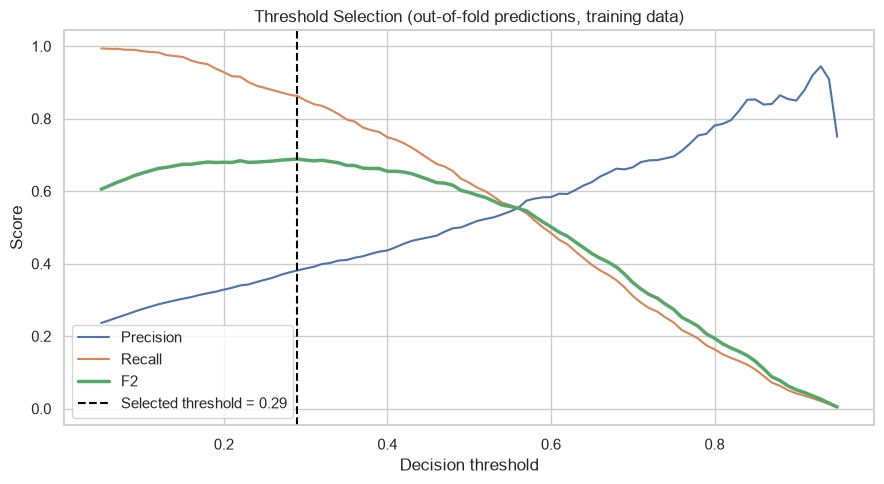

In [40]:
final_model = fitted["Random Forest (tuned)"]

oof_proba = cross_val_predict(
    clone(final_model),
    X_train,
    y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    method="predict_proba",
    n_jobs=-1,
)[:, 1]

thresholds = np.linspace(0.05, 0.95, 91)
f2_scores = [fbeta_score(y_train, oof_proba >= t, beta=2, zero_division=0) for t in thresholds]
precisions = [precision_score(y_train, oof_proba >= t, zero_division=0) for t in thresholds]
recalls = [recall_score(y_train, oof_proba >= t, zero_division=0) for t in thresholds]

best_threshold = float(thresholds[int(np.argmax(f2_scores))])

plt.figure(figsize=(9, 5))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, f2_scores, label="F2", linewidth=2.5)
plt.axvline(best_threshold, color="black", linestyle="--", label=f"Selected threshold = {best_threshold:.2f}")
plt.title("Threshold Selection (out-of-fold predictions, training data)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.legend()
save_show("10_threshold_selection")

In [41]:
threshold_table = pd.DataFrame([
    evaluate(final_model, X_test, y_test, threshold=0.5, name="Random Forest (tuned) @ 0.50"),
    evaluate(final_model, X_test, y_test, threshold=best_threshold, name=f"Random Forest (tuned) @ {best_threshold:.2f}"),
]).set_index("Model")

threshold_table

,Accuracy,Precision,Recall,F1,F2,ROC-AUC,PR-AUC
Model,,,,,,,
Random Forest (tuned) @ 0.50,0.820,0.520,0.658,0.581,0.625,0.866,0.629
Random Forest (tuned) @ 0.29,0.707,0.382,0.886,0.534,0.701,0.866,0.629


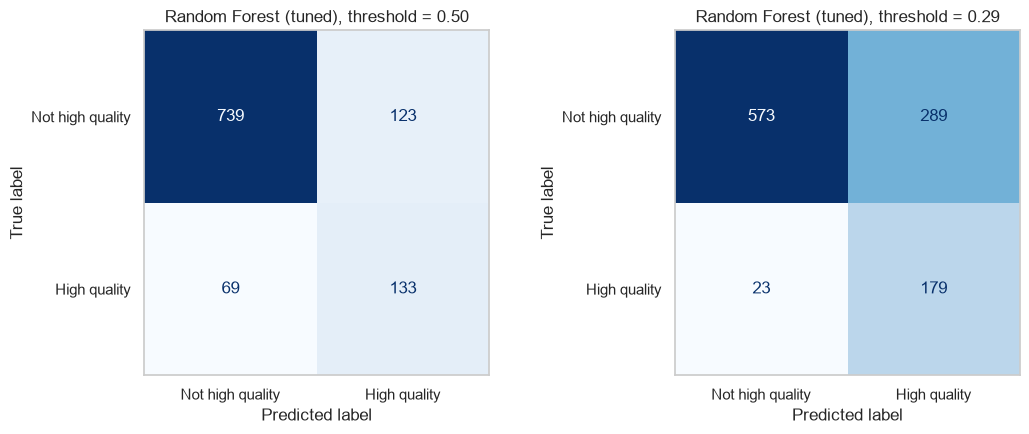

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, thr in zip(axes, [0.5, best_threshold]):
    pred = (final_model.predict_proba(X_test)[:, 1] >= thr).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, ax=ax, cmap="Blues", colorbar=False,
        display_labels=["Not high quality", "High quality"],
    )
    ax.set_title(f"Random Forest (tuned), threshold = {thr:.2f}")
    ax.grid(False)

save_show("11_confusion_matrices")

Lowering the threshold trades precision for recall: more truly high-quality wines are caught, at the price of sending more ordinary wines to the panel. Where the threshold should sit is a **business decision**, and this analysis makes that trade-off explicit.

### Screening workload: how many batches would go to the sensory panel?

For a QC manager, the practical questions are *how many batches would be flagged* (panel workload) and *how many high-quality wines would be found* in exchange. **Lift** compares the precision of the flagged group with the overall share of high-quality wines.

In [43]:
test_proba = final_model.predict_proba(X_test)[:, 1]
y_arr = y_test.values

flag_rows = []
for thr in [0.50, best_threshold]:
    flagged = test_proba >= thr
    flag_rows.append({
        "threshold": round(thr, 2),
        "% of batches flagged": flagged.mean() * 100,
        "precision": y_arr[flagged].mean(),
        "recall": flagged[y_arr == 1].mean(),
        "lift vs. random": y_arr[flagged].mean() / y_arr.mean(),
    })

flag_table = pd.DataFrame(flag_rows).set_index("threshold")
flag_table

,% of batches flagged,precision,recall,lift vs. random
threshold,,,,
0.500,24.060,0.520,0.658,2.737
0.290,43.985,0.382,0.886,2.015


Read the table as a trade-off between **workload** and **coverage**: the lower threshold sends more batches to the panel but finds a much larger share of the high-quality wines than random selection of the same number of batches would. Which row is preferable depends on panel capacity and on the cost of missing a premium batch.

## 6.8 Five-fold stratified cross-validation

To check stability beyond a single split, the default (untuned) models and the baseline are evaluated with 5-fold stratified cross-validation on the full cleaned dataset. The tuned model is excluded here on purpose: its hyperparameters were chosen using the training portion of these same rows, so including it would be slightly optimistic. Scaling for Logistic Regression is fitted inside each training fold through the Pipeline.

In [44]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
}

cv_models = {
    "Dummy (baseline)": DummyClassifier(strategy="prior"),
    "Logistic Regression": make_logreg(),
    "Random Forest (default)": make_rf(),
}

cv_rows = []
for name, model in cv_models.items():
    res = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Model": name}
    for metric in scoring:
        scores = res[f"test_{metric}"]
        row[metric] = f"{scores.mean():.3f} ± {scores.std():.3f}"
    cv_rows.append(row)

cv_summary = pd.DataFrame(cv_rows).set_index("Model")
cv_summary

,accuracy,precision,recall,f1,roc_auc,pr_auc
Model,,,,,,
Dummy (baseline),0.810 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.000 ± 0.000,0.500 ± 0.000,0.190 ± 0.000
Logistic Regression,0.739 ± 0.020,0.405 ± 0.022,0.787 ± 0.022,0.534 ± 0.024,0.829 ± 0.018,0.514 ± 0.022
Random Forest (default),0.827 ± 0.018,0.543 ± 0.043,0.593 ± 0.028,0.566 ± 0.034,0.859 ± 0.013,0.600 ± 0.027


Values are mean ± standard deviation across the five folds. Small standard deviations indicate that the comparison between models does not depend on one particular split.

## 6.9 Do domain-informed features add predictive value?

The Random Forest is compared with and without the two engineered SO₂ features from Section 4.6, using the same cross-validation folds.

In [45]:
X_eng = wine[FEATURES + ENGINEERED].copy()

feature_sets = {
    "11 original variables": X,
    "Original + molecular SO₂ features": X_eng,
}

fs_rows = []
fs_means = {}
for name, features in feature_sets.items():
    res = cross_validate(
        make_rf(), features, y, cv=cv,
        scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"},
        n_jobs=-1,
    )
    fs_means[name] = res["test_pr_auc"].mean()
    fs_rows.append({
        "Feature set": name,
        "ROC-AUC": f"{res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}",
        "PR-AUC": f"{res['test_pr_auc'].mean():.3f} ± {res['test_pr_auc'].std():.3f}",
        "F1": f"{res['test_f1'].mean():.3f} ± {res['test_f1'].std():.3f}",
    })

pd.DataFrame(fs_rows).set_index("Feature set")

,ROC-AUC,PR-AUC,F1
Feature set,,,
11 original variables,0.859 ± 0.013,0.600 ± 0.027,0.566 ± 0.034
Original + molecular SO₂ features,0.861 ± 0.011,0.601 ± 0.021,0.565 ± 0.018


# 7. Model Interpretation

Two complementary importance measures are computed for the tuned Random Forest:

- **Impurity-based importance:** contribution of each variable to reducing impurity across the trees (computed on training data; can favour variables with many distinct values).
- **Permutation importance:** drop in test-set PR-AUC when a variable is shuffled (model-agnostic and computed on unseen data).

Both describe **predictive** importance, not causal importance. Because several predictors are correlated (Section 4.4), importance can be shared or understated among related variables such as alcohol, density and residual sugar.

In [46]:
impurity_importance = pd.DataFrame({
    "variable": X_train.columns,
    "importance": final_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

perm = permutation_importance(
    final_model, X_test, y_test,
    n_repeats=10, random_state=RANDOM_STATE, scoring="average_precision", n_jobs=-1,
)
permutation_results = pd.DataFrame({
    "variable": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(impurity_importance)
display(permutation_results)

,variable,importance
0,alcohol,0.214
1,density,0.121
2,volatile acidity,0.088
3,chlorides,0.085
4,total sulfur dioxide,0.078
5,citric acid,0.076
6,sulphates,0.075
7,pH,0.069
8,free sulfur dioxide,0.068
9,residual sugar,0.066


,variable,importance_mean,importance_std
0,alcohol,0.258,0.035
1,chlorides,0.086,0.019
2,density,0.083,0.020
3,free sulfur dioxide,0.061,0.014
4,residual sugar,0.057,0.009
5,volatile acidity,0.052,0.010
6,total sulfur dioxide,0.042,0.019
7,citric acid,0.042,0.014
8,sulphates,0.040,0.008
9,fixed acidity,0.028,0.012


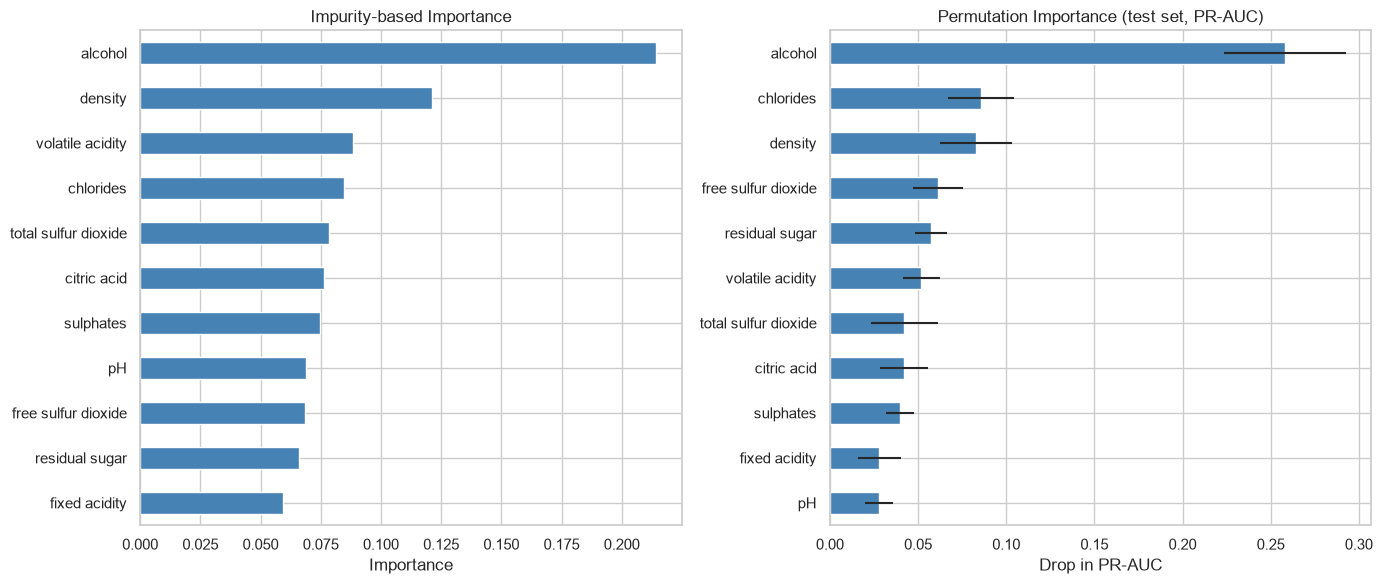

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

impurity_importance.sort_values("importance").plot(
    kind="barh", x="variable", y="importance", ax=axes[0], legend=False, color="steelblue")
axes[0].set(title="Impurity-based Importance", xlabel="Importance", ylabel="")

permutation_results.sort_values("importance_mean").plot(
    kind="barh", x="variable", y="importance_mean", xerr="importance_std",
    ax=axes[1], legend=False, color="steelblue")
axes[1].set(title="Permutation Importance (test set, PR-AUC)", xlabel="Drop in PR-AUC", ylabel="")
save_show("12_feature_importance")

In [48]:
top_impurity = impurity_importance["variable"].head(4).tolist()
top_perm = permutation_results["variable"].head(4).tolist()
top_eta = eta_table["variable"].head(4).tolist()
top_spearman = spearman_all.abs().sort_values(ascending=False).head(4).index.tolist()

agreement = pd.DataFrame({
    "Spearman |ρ|": top_spearman,
    "Kruskal η²ₕ": top_eta,
    "Impurity importance": top_impurity,
    "Permutation importance": top_perm,
}, index=[f"#{i}" for i in range(1, 5)])

display(Markdown("**Top 4 variables according to each method:**"))
agreement

**Top 4 variables according to each method:**

,Spearman |ρ|,Kruskal η²ₕ,Impurity importance,Permutation importance
#1,alcohol,alcohol,alcohol,alcohol
#2,density,density,density,chlorides
#3,chlorides,chlorides,volatile acidity,density
#4,volatile acidity,volatile acidity,chlorides,free sulfur dioxide


Variables that appear in the top positions across all four methods are the most consistently relevant. Where the rankings disagree, the explanation usually lies in the distinct question each method answers (monotonic association, group difference, or predictive contribution) and in correlated predictors, so disagreement should be reported rather than hidden.

# 8. Results Summary (auto-generated)

The figures below are computed from the code above.

In [49]:
strongest = spearman_all.abs().idxmax()
best_model_name = "Random Forest (tuned)"   # final model, selected using training data only
best_row = holdout_table.loc[best_model_name]
base_row = holdout_table.loc["Dummy (baseline)"]
thr_row = threshold_table.iloc[1]
thr_default = threshold_table.iloc[0]

f_default, f_screen = flag_table.iloc[0], flag_table.iloc[1]

eng_gain = fs_means["Original + molecular SO₂ features"] - fs_means["11 original variables"]

summary_md = f"""
**Data audit.** {n_raw:,} records → {n_dup:,} exact duplicates removed ({n_dup / n_raw:.1%}) → **{n_clean:,} unique wines** analysed ({n_red:,} red, {n_white:,} white).

**Associations with quality.** The variable most associated with quality is **{strongest}** (Spearman ρ = {spearman_all[strongest]:+.2f}). The largest group-difference effects across quality segments are **{', '.join(top_eta)}** (η²ₕ = {', '.join(f'{v:.2f}' for v in eta_table['eta2_H'].head(4))}).

**Density.** Alcohol and residual sugar explain {r2_all:.0%} of the variance in density, so density is {strength} a proxy for them.

**Model performance (test set).** Against a no-skill PR-AUC of {base_row['PR-AUC']:.2f}, the final model (**{best_model_name}**) reaches PR-AUC {best_row['PR-AUC']:.2f} and ROC-AUC {best_row['ROC-AUC']:.2f}.

**Threshold trade-off.** At the default threshold 0.50 the tuned Random Forest has precision {thr_default['Precision']:.2f} and recall {thr_default['Recall']:.2f}. At the screening threshold {best_threshold:.2f} (F2-optimised on training data) it reaches precision {thr_row['Precision']:.2f} and recall {thr_row['Recall']:.2f}.

**Screening workload (test set).** At threshold {best_threshold:.2f}, {f_screen['% of batches flagged']:.0f}% of batches are sent to the sensory panel and {f_screen['recall']:.0%} of the high-quality wines are captured, versus {f_screen['% of batches flagged']:.0f}% captured if the same share of batches were chosen at random. At threshold 0.50, {f_default['% of batches flagged']:.0f}% of batches are flagged and {f_default['recall']:.0%} of the high-quality wines are captured.

**Domain features.** Adding molecular SO₂ and the free/total SO₂ ratio changed cross-validated PR-AUC by {eng_gain:+.3f}.
"""

display(Markdown(summary_md))


**Data audit.** 6,497 records → 1,177 exact duplicates removed (18.1%) → **5,320 unique wines** analysed (1,359 red, 3,961 white).

**Associations with quality.** The variable most associated with quality is **alcohol** (Spearman ρ = +0.48). The largest group-difference effects across quality segments are **alcohol, density, chlorides, volatile acidity** (η²ₕ = 0.24, 0.13, 0.10, 0.07).

**Density.** Alcohol and residual sugar explain 56% of the variance in density, so density is partly a proxy for them.

**Model performance (test set).** Against a no-skill PR-AUC of 0.19, the final model (**Random Forest (tuned)**) reaches PR-AUC 0.63 and ROC-AUC 0.87.

**Threshold trade-off.** At the default threshold 0.50 the tuned Random Forest has precision 0.52 and recall 0.66. At the screening threshold 0.29 (F2-optimised on training data) it reaches precision 0.38 and recall 0.89.

**Screening workload (test set).** At threshold 0.29, 44% of batches are sent to the sensory panel and 89% of the high-quality wines are captured, versus 44% captured if the same share of batches were chosen at random. At threshold 0.50, 24% of batches are flagged and 66% of the high-quality wines are captured.

**Domain features.** Adding molecular SO₂ and the free/total SO₂ ratio changed cross-validated PR-AUC by +0.001.


# 9. Business Insights

> Read these together with the Results Summary above. They describe associations, not causes.

### 1. Alcohol is the most consistent correlate of quality

Alcohol ranks at or near the top across correlation, group-difference and predictive analyses. Chemically, alcohol is largely a consequence of the sugar accumulated by the grapes at harvest, so it may partly reflect **grape ripeness**, and ethanol also contributes to body and mouthfeel. **QC implication:** harvest ripeness indicators (sugar/potential alcohol at reception) deserve attention as early quality signals.

### 2. Density is a convenient proxy, not an independent lever

Density is cheap and fast to measure, which makes it attractive for routine screening. However, it is substantially determined by ethanol and sugar (Section 4.5), so it should be monitored as a **summary indicator**, not interpreted as a separate cause.

### 3. Volatile acidity points to microbiological and process control

Volatile acidity is mainly acetic acid, a well-known marker of spoilage or fermentation problems. A negative association with sensory quality is chemically coherent. **QC implication:** routine acetic acid monitoring and hygiene control remain well-founded priorities.

### 4. Chlorides should be interpreted with caution

Chlorides are negatively associated with quality, but they also differ strongly with wine type and may reflect vineyard conditions or practices rather than winemaking decisions. The within-type analysis (Section 5.3) shows how robust this association is.

### 5. SO₂ protection depends on pH

Free SO₂ alone is an incomplete indicator because its protective molecular fraction depends on pH. Section 6.9 tests whether encoding this relationship improves prediction; regardless of the result, QC practice should read free SO₂ and pH together.

### 6. The right model depends on the cost of errors

A screening tool can be tuned towards catching more high-quality wines (higher recall) or towards sending fewer ordinary wines to the panel (higher precision). The threshold analysis makes this trade-off explicit, and the choice belongs to the business.

# 10. Limitations

- **Observational data:** only associations can be established, not causal effects.
- **Subjective, ordinal target:** quality is the median of at least three tasters' scores; panel variability and the ordinal nature of the scale limit precision.
- **Arbitrary class definitions:** `quality ≥ 7` (and the Low/Medium/High segments) are analytical choices, not validated production standards.
- **Class imbalance:** high-quality wines are a minority, so metrics such as PR-AUC are more informative than accuracy.
- **Duplicates:** the dataset has no sample identifier, so duplicated records were assumed to be repeated entries rather than genuine replicates.
- **Correlated predictors:** alcohol, sugar and density are physically linked, so variable importance cannot be attributed to a single variable with certainty.
- **Wine type excluded from the model:** red and white wines are chemically different; a combined model may average over type-specific relationships.
- **Assumed costs:** the F2-based threshold rests on an illustrative cost assumption.
- **Scope:** *Vinho Verde* wines from one region and period; no information on grape variety, vintage, producer or price. Results should not be generalised to other wine styles or regions.
- **Validation:** a single holdout plus cross-validation; a production system would need an external validation set.

# 11. Conclusions & Next Steps

This analysis combined a data audit, chemistry-aware exploratory analysis, robust non-parametric statistics with effect sizes, and leakage-safe machine learning to link laboratory measurements with sensory quality. The most consistent findings are summarised in **Section 8**, and their enological interpretation in **Section 9**.

Methodologically, the project shows the importance of auditing the data before modelling (for example, removing repeated records before splitting the data), comparing against a baseline, choosing the decision threshold from the cost of errors rather than defaulting to 0.5, and interpreting variable importance in the light of the underlying chemistry.

### Possible extensions

1. Separate models for red and white wines, and an interaction analysis (e.g. pH × free SO₂).
2. SHAP values for local explanations of individual predictions.
3. Ordinal regression to model the full 3–9 scale instead of a binary target.
4. Probability calibration of the final model.
5. Validation with production data and statistical process control (SPC) charts on longitudinal batch measurements.
6. Letting actual panel and re-tasting costs define the screening threshold.